### [SVM 분류 실습 : Fish 데이터셋 - Bream vs Smelt]

**목표**
    - 데이터 : fish.csv
    - 품_종 : Bream, Smelt
    - 피처 : Length, Weight

    - Pipeline(전처리 RobustScaler, LabelEncoder, SVC 모델) 
    - GridSearch CV로 교차검증, 튜닝 진행
    - 산점도와 결정경계선(Decision Boundary) 시각화


In [14]:
# 모듈 로딩
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
## ML 전처리 관련
from sklearn.preprocessing import RobustScaler

## ML 파이프라인 관련
from sklearn.pipeline import Pipeline

## ML 모델 관련
from sklearn.svm import SVC

## ML 성능지표 관련
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import ( train_test_split, StratifiedKFold, GridSearchCV)
from sklearn.metrics import ( accuracy_score, confusion_matrix, classification_report)

In [18]:
## 데이터 임포트
# 데이터 로딩
DATA_FILE= '../Data/Numbers/fish.csv'
fishDF = pd.read_csv(DATA_FILE, usecols= ['Species', 'Length', 'Weight'], skiprows=range(36, 146))

# Bream, Smelt만 추출
fishDF = fishDF[fishDF['Species'].isin(['Bream', 'Smelt'])].copy()


print(fishDF.head())
print(fishDF['Species'].value_counts())

  Species  Weight  Length
0   Bream   242.0    25.4
1   Bream   290.0    26.3
2   Bream   340.0    26.5
3   Bream   363.0    29.0
4   Bream   430.0    29.0
Species
Bream    35
Smelt    14
Name: count, dtype: int64


In [ ]:
fishDF.describe(include='all')


##=> 해석
##- Weight, Length : 값의 차이가 큼 => 스케일링 필요
##- Species : 범주형 => str ---category 형변환
 


,Species,Weight,Length
count,49,49.000000,49.000000
unique,2,NaN,NaN
top,Bream,NaN,NaN
freq,35,NaN,NaN
mean,NaN,444.500000,27.055102
std,NaN,328.143233,10.242804
min,NaN,6.700000,9.800000
25%,NaN,19.700000,14.300000
50%,NaN,500.000000,31.000000
75%,NaN,700.000000,34.500000


**[2] 데이터셋 분리**

In [24]:
# 피처와 타깃 분리
featureDF= fishDF[fishDF.columns[1:]]
targetSR= fishDF[fishDF.columns[0]]
X = fishDF[['Length', 'Weight']]
y = fishDF['Species']

# LabelEncoder: 문자열 품종 → 숫자
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print('클래스:', encoder.classes_)
print('변환 결과:', dict(zip( encoder.classes_, encoder.transform(encoder.classes_))))

featureDF.shape

클래스: ['Bream' 'Smelt']
변환 결과: {'Bream': np.int64(0), 'Smelt': np.int64(1)}


(49, 2)

In [23]:
# 학습/테스트 데이터 분리
## 훈련/테스트 데이터 셋 분리 => 클래스 비율유지 : stratify 매개변수 설정
X_train, X_test, y_train, y_test = train_test_split(featureDF,
                                                    targetSR,
                                                    test_size=0.2,
                                                    shuffle = True,
                                                    random_state = 12,
                                                    stratify=targetSR)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (39, 2)
X_test : (10, 2)


In [25]:
print(f'[TRAIN]\n{X_train.shape}, {y_train.shape}')
print(f'클래스비율: {y_train.value_counts(normalize=True).round(1).tolist()}\n')

print(f'[TEST]\n{X_test.shape}, {y_test.shape}')
print(f'클래스비율: {y_test.value_counts(normalize=True).round(1).tolist()}\n')

[TRAIN]
(39, 2), (39,)
클래스비율: [0.7, 0.3]

[TEST]
(10, 2), (10,)
클래스비율: [0.7, 0.3]



**[3] 파이프라인+ 교차검증+ 튜닝 준비**

In [33]:
## => SVC 모델: 불균형 데이터=> class_weight
## 파이프라인 인스턴스
pipe = Pipeline(steps=[ ('rbScalar', RobustScaler()), ('svcModel', SVC(class_weight= 'balanced')),

])


skFold= StratifiedKFold(shuffle= True, random_state=12)

## 하이퍼파라미터 설정: 모델 변수명_ _파라미터
## => 조합으로 15개 모델 생성
params= {'svcModel__C': [0.1, 0.5, 1.0, 5, 10], 
          'svcModel__kernel':['rbf','linear', 'poly']}


## 교차검증+튜닝 인스턴스 생성
tunning = GridSearchCV(pipe,
                        cv=skFold, 
                        param_grid=params, 
                        scoring=['accuracy', 'f1_macro', 'f1_weighted'],
                        refit='f1_macro')

tunning

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=12, shuffle=True),
             estimator=Pipeline(steps=[('rbScalar', RobustScaler()),
                                       ('svcModel',
                                        SVC(class_weight='balanced'))]),
             param_grid={'svcModel__C': [0.1, 0.5, 1.0, 5, 10],
                         'svcModel__kernel': ['rbf', 'linear', 'poly']},
             refit='f1_macro', scoring=['accuracy', 'f1_macro', 'f1_weighted'])

In [34]:
tunning.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=12, shuffle=True),
             estimator=Pipeline(steps=[('rbScalar', RobustScaler()),
                                       ('svcModel',
                                        SVC(class_weight='balanced'))]),
             param_grid={'svcModel__C': [0.1, 0.5, 1.0, 5, 10],
                         'svcModel__kernel': ['rbf', 'linear', 'poly']},
             refit='f1_macro', scoring=['accuracy', 'f1_macro', 'f1_weighted'])

- **[5] 교차검증+ 튜닝결과**

In [36]:
## => 최고 파라미터, 최고 점수, 최고 모델 추출
print(f'best_params_ : {tunning.best_params_}')
print(f'best_score_: {tunning. best_score_} ')

bestModel = tunning.best_estimator_

best_params_ : {'svcModel__C': 0.1, 'svcModel__kernel': 'rbf'}
best_score_: 1.0 


In [37]:
## 상세 학습/ 겸증 결과
tunning.cv

StratifiedKFold(n_splits=5, random_state=12, shuffle=True)

**[6] 테스트 진행**

In [40]:
## 학습/ 테스트 데이터셋으로 평가 진행

y_pre= bestModel.predict(X_test)

test_score= bestModel.score(X_test, y_test)
train_score= bestModel.score(X_train, y_train)

print(f' 훈련점수: {train_score}, 테스트 점수: {test_score}')

 훈련점수: 1.0, 테스트 점수: 1.0


In [43]:
## => 컨퓨전매트릭스
condata = confusion_matrix(y_test, y_pre)
pd. DataFrame(condata, index=[['ACT', 'ACT' ], ['N','P']], columns=[['Model', 'Model' ], ['N', 'P']])

Model   
          N  P
ACT N     7  0
    P     0  3

In [44]:
 

print('테스트 정확도:', accuracy_score(y_test, y_pre))
print('혼동행렬:\n', confusion_matrix(y_test, y_pre))

print(classification_report(
    y_test,
    y_pre,
    target_names=encoder.classes_,
    zero_division=0
))

테스트 정확도: 1.0
혼동행렬:
 [[7 0]
 [0 3]]
              precision    recall  f1-score   support

       Bream       1.00      1.00      1.00         7
       Smelt       1.00      1.00      1.00         3

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



**[6] 테스트**

In [54]:
## => 학습/테스트 데이터셋으로 평가 진행
## 예측값 추출
y_pre = bestModel. predict(X_test)
decision_value = bestModel.decision_function(X_test)
print(decision_value)

## 점수 계산
test_score = bestModel.score(X_test, y_test)
train_score = bestModel.score(X_train, y_train)

print(f'훈_련 점수 : {train_score} , 테스트점수: {test_score}')


## 클래스 결정 계산값 : decision_function()
## > 0 -- 양성 : Smelt
## < 0 -- 음성 : Bream
decision_value = bestModel.decision_function(X_test)
print(bestModel.classes_)
print(decision_value)
print(y_test.to_list())



[-0.91814682 -0.95407115  0.99961102 -0.57678552 -0.99963458  0.97970631
 -0.75221019  1.00209369 -0.98998218 -0.77209242]
훈_련 점수 : 1.0 , 테스트점수: 1.0
['Bream' 'Smelt']
[-0.91814682 -0.95407115  0.99961102 -0.57678552 -0.99963458  0.97970631
 -0.75221019  1.00209369 -0.98998218 -0.77209242]
['Bream', 'Bream', 'Smelt', 'Bream', 'Bream', 'Smelt', 'Bream', 'Smelt', 'Bream', 'Bream']


Model   
          N  P
ACT N     7  0
    P     0  3

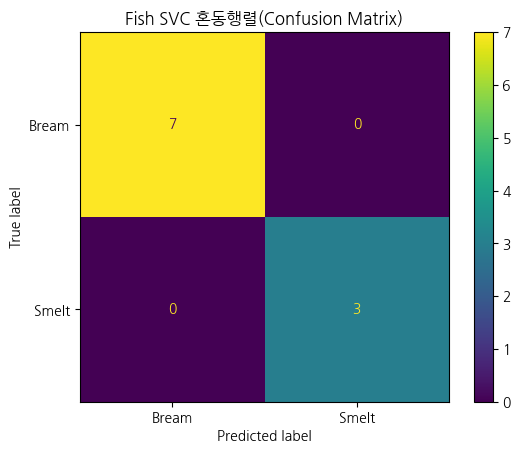

In [58]:
## => 혼동행렬 : accuracy, precision, recall, f1-score 계산용 표
condata = confusion_matrix(y_test, y_pre)
conDF= pd. DataFrame (condata,index=[['ACT', 'ACT' ], ['N','P']],columns=[['Model', 'Model' ], ['N', 'P']])



display(conDF)

## => 시각화 : ConfusionMatrixDisplay()
disp = ConfusionMatrixDisplay( confusion_matrix=condata,
display_labels=bestModel.classes_ )

disp.plot()
plt.title("Fish SVC 혼동행렬(Confusion Matrix)")
plt.show()

In [60]:
## -------------------------------------------------------------
## 함수이름 : plot_decision_boundary_2d
## 함수기능 : 결정경계 시각화 함수
## 매개변수 : model
##           X - DataFrame
##           y - 
##           title - 제목
## 함수결과 : 없음
## -------------------------------------------------------------
def plot_decision_boundary_2d(model, X, y, title):
    ## 모든행의 최소/최대 찾기
    x_min, x_max = X.iloc[:, 0].min() - 1, X.iloc[:, 0].max() + 1
    y_min, y_max = X.iloc[:, 1].min() - 20, X.iloc[:, 1].max() + 20


    ## 격자 좌표 생성
    ## 길이, 무게 크기 범위안에서 데이터 500개 생성
    xx, yy = np.meshgrid( np.linspace(x_min, x_max, 500),
                          np.linspace(y_min, y_max, 500))

    ## 격자 데이터를 원래 피처명과 같은 DataFrame으로 생성
    grid_points = pd.DataFrame( np.c_[xx.ravel(), yy.ravel()], columns=X.columns  )

    ## 각 격자점에 대한 클래스 예측 => 양수 Smelt, 0 경계선, 음수 Bream
    Z = model.predict(grid_points)

    ## 문자 라벨을 숫자로 변환해서 contourf에 사용
    classes = np.array(model.classes_)
    Z_num = np.array([np.where(classes == label)[0][0] for label in Z])
    Z_num = Z_num.reshape(xx.shape)
    plt.figure(figsize=(8, 6))


    # 결정 영역
    plt.contourf(xx, yy, Z_num, alpha=0.25)


    # 결정 경계선
    plt.contour(xx, yy, Z_num, levels=[0.5], linewidths=2)


    # 실제 데이터 산점도
    for label in classes:
        temp = X[y == label]
        plt.scatter( temp.iloc[:, 0], temp.iloc[:, 1], label=label,  edgecolor="k", alpha=0.8  )
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title(title)
    plt.legend()
    plt.show()


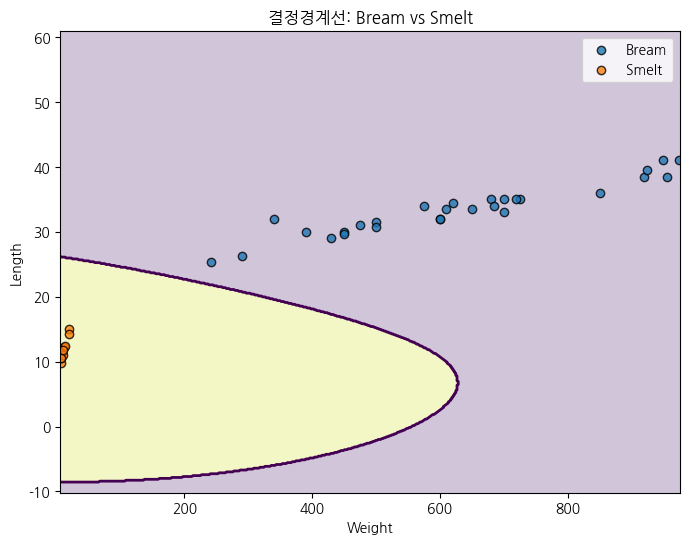

In [61]:
plot_decision_boundary_2d( bestModel, X_train, y_train, "결정경계선: Bream vs Smelt" )

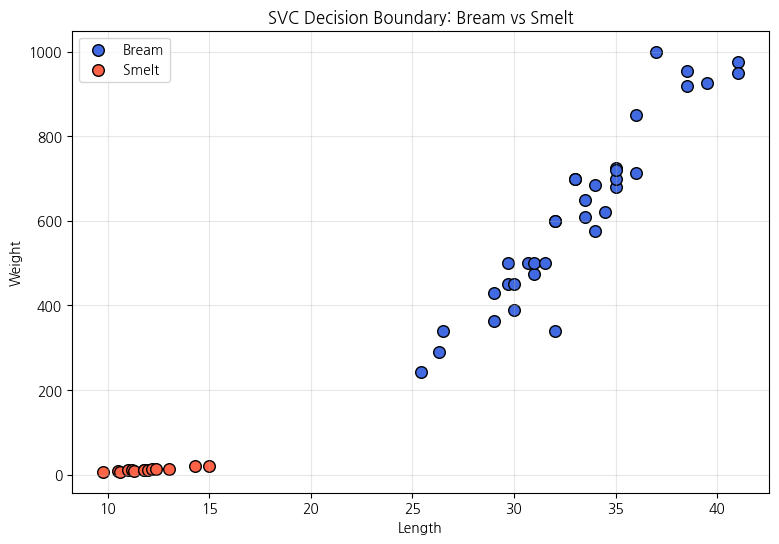